In [24]:
# ==============================================
# TRABALHO 1 - TRATAMENTO DE DADOS HIDROLÓGICOS
# ==============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import linregress
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
dfJ = pd.read_csv('/content/drive/My Drive/IA/Trabalho 1 - IA/Estações Joinville/Estação Joinville RVPSC-2648014.csv')
dfI = pd.read_csv('/content/drive/My Drive/IA/Trabalho 1 - IA/Estações Joinville/Estação Itapocu 2648020.csv')
dfP = pd.read_csv('/content/drive/My Drive/IA/Trabalho 1 - IA/Estações Joinville/Estação Ponte SC-301 2648028.csv')

In [26]:
# ==========================
# LEITURA E ANÁLISE INICIAL
# ==========================
print("\nDimensão do banco:", dfJ.shape)
print("\nColunas:", dfJ.columns[:10])
print("\nValores nulos por coluna:\n", dfJ.isnull().sum().sort_values(ascending=False).head(10))

print("\nDimensão do banco:", dfI.shape)
print("\nColunas:", dfI.columns[:10])
print("\nValores nulos por coluna:\n", dfI.isnull().sum().sort_values(ascending=False).head(10))

print("\nDimensão do banco:", dfP.shape)
print("\nColunas:", dfP.columns[:10])
print("\nValores nulos por coluna:\n", dfP.isnull().sum().sort_values(ascending=False).head(10))


Dimensão do banco: (1656, 75)

Colunas: Index(['EstacaoCodigo', 'NivelConsistencia', 'Data', 'TipoMedicaoChuvas',
       'Maxima', 'Total', 'DiaMaxima', 'NumDiasDeChuva', 'MaximaStatus',
       'TotalStatus'],
      dtype='object')

Valores nulos por coluna:
 Chuva31           729
TotalAnual        396
Chuva30           203
Chuva29           170
NumDiasDeChuva    153
Maxima            146
DiaMaxima         146
Chuva19            94
Chuva07            93
Chuva12            92
dtype: int64

Dimensão do banco: (898, 75)

Colunas: Index(['EstacaoCodigo', 'NivelConsistencia', 'Data', 'TipoMedicaoChuvas',
       'Maxima', 'Total', 'DiaMaxima', 'NumDiasDeChuva', 'MaximaStatus',
       'TotalStatus'],
      dtype='object')

Valores nulos por coluna:
 Chuva31           384
TotalAnual        370
Chuva30            87
Chuva29            69
NumDiasDeChuva     32
Maxima             28
DiaMaxima          28
Chuva11            18
Chuva02            17
Chuva15            17
dtype: int64

Dimensão do 

In [36]:
def prep_df(df):

    df = df.copy()

    if 'Data' in df.columns:
        df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
        df = df.sort_values('Data')

    status_cols = [c for c in df.columns if 'Status' in c]
    df = df.drop(columns=status_cols, errors='ignore')

    df = df.ffill().bfill()

    return df

dfJ = prep_df(dfJ)
dfI = prep_df(dfI)
dfP = prep_df(dfP)


=== Joinville | Total ANUAL x Nº de dias de chuva ===
           Ano    Total  NumDiasDeChuva
count    85.00    85.00           85.00
mean   1980.99  2585.51          215.29
std      25.56   999.00           82.66
min    1938.00   344.60           14.00
25%    1959.00  1802.50          156.00
50%    1980.00  2409.60          200.00
75%    2003.00  3193.90          272.00
max    2024.00  5687.80          411.00

Correlação de Pearson: 0.696
p-value da inclinação: 1.351e-13
Obs.: p < 0.05 indica relação significativa.


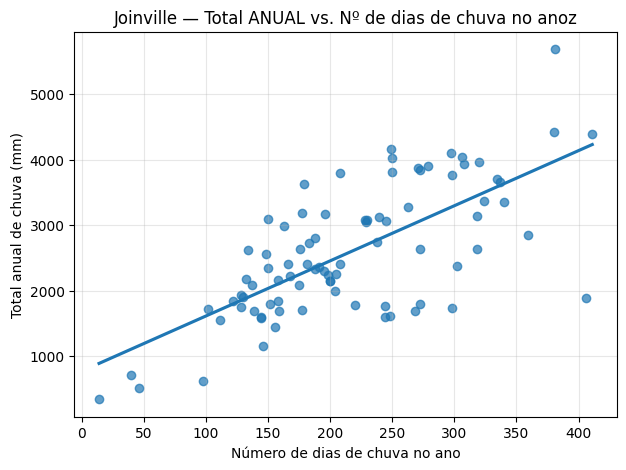


=== Itapocu | Total ANUAL x Nº de dias de chuva ===
           Ano    Total  NumDiasDeChuva
count    49.00    49.00           49.00
mean   2000.00  2506.00          232.33
std      14.29  1536.57           76.37
min    1976.00   199.90           89.00
25%    1988.00  1152.00          166.00
50%    2000.00  2233.10          226.00
75%    2012.00  3784.60          290.00
max    2024.00  5829.80          386.00

Correlação de Pearson: 0.848
p-value da inclinação: 1.388e-14
Obs.: p < 0.05 indica relação significativa.


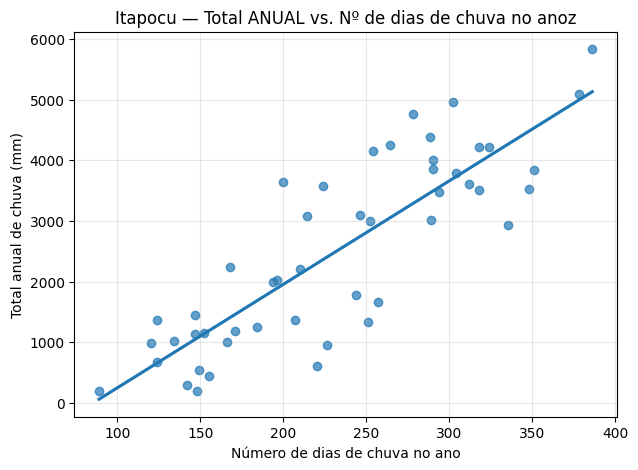


=== Ponte SC-301 | Total ANUAL x Nº de dias de chuva ===
           Ano    Total  NumDiasDeChuva
count    47.00    47.00           47.00
mean   2000.68  2663.57          240.23
std      14.09  1039.37           73.74
min    1977.00  1342.60           68.00
25%    1988.50  1803.05          194.00
50%    2001.00  2506.00          234.00
75%    2012.50  3265.25          262.50
max    2024.00  5799.60          438.00

Correlação de Pearson: 0.365
p-value da inclinação: 1.172e-02
Obs.: p < 0.05 indica relação significativa.


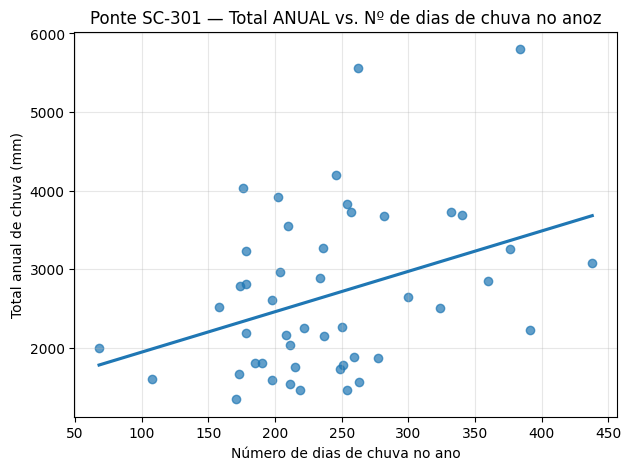

In [37]:
def analisa_total_anual(df, nome='Estação'):

    if not {'Total','NumDiasDeChuva','Data'}.issubset(df.columns):
        print(f"{nome}: faltam colunas 'Total', 'NumDiasDeChuva' e/ou 'Data'.")
        return

    base = df.dropna(subset=['Data'])[['Data','Total','NumDiasDeChuva']].copy()
    base['Ano'] = base['Data'].dt.year
    base = base.groupby('Ano', as_index=False)[['Total','NumDiasDeChuva']].sum()

    if base.empty:
        print(f"{nome}: base anual vazia.")
        return

    print(f"\n=== {nome} | Total ANUAL x Nº de dias de chuva ===")
    print(base.describe().round(2))

    corr = base['Total'].corr(base['NumDiasDeChuva'])
    lr = linregress(base['NumDiasDeChuva'], base['Total'])
    print(f"\nCorrelação de Pearson: {corr:.3f}")
    print(f"p-value da inclinação: {lr.pvalue:.3e}")
    print("Obs.: p < 0.05 indica relação significativa.")

    plt.figure(figsize=(7,5))
    sns.regplot(x='NumDiasDeChuva', y='Total', data=base, ci=None, scatter_kws={'alpha':0.7})
    plt.title(f'{nome} — Total ANUAL vs. Nº de dias de chuva no anoz')
    plt.xlabel('Número de dias de chuva no ano')
    plt.ylabel('Total anual de chuva (mm)')
    plt.grid(True, alpha=0.3)
    plt.show()


analisa_total_anual(dfJ, 'Joinville')
analisa_total_anual(dfI, 'Itapocu')
analisa_total_anual(dfP, 'Ponte SC-301')

In [38]:
def teste_sazonalidade(df, nome='Estação'):
    d = df.copy()
    if 'Data' in d.columns:
        d['Ano'] = d['Data'].dt.year
        d['Mes'] = d['Data'].dt.month

    if 'Maxima_Anual' not in d.columns and 'Maxima' in d.columns and 'Ano' in d.columns:
        max_anuais = d.groupby('Ano')['Maxima'].max().reset_index().rename(columns={'Maxima':'Maxima_Anual'})
        d = d.merge(max_anuais, on='Ano', how='left')

    if not {'Mes','Maxima','Maxima_Anual'}.issubset(d.columns):
        print(f"{nome}: faltam colunas para o teste (Mes/Maxima/Maxima_Anual).")
        return

    d = d.dropna(subset=['Mes','Maxima','Maxima_Anual']).copy()
    d['Mes_Max_Anual'] = (d['Maxima'] == d['Maxima_Anual']).astype(int)

    X = pd.get_dummies(d['Mes'], prefix='Mes', drop_first=False)
    y = d['Mes_Max_Anual']
    chi_vals, p_vals = chi2(X, y)
    res = pd.DataFrame({'Chi2': chi_vals, 'p-value': p_vals}, index=X.columns).sort_values('p-value')

    print(f"\n--- Teste de Sazonalidade (Chi²) — {nome} ---")
    res_fmt = res.copy(); res_fmt['p-value'] = res_fmt['p-value'].apply(lambda v: f"{v:.3e}")
    print(res_fmt)
    print('Se p < 0.05, há concentração dos máximos em certos meses.')
    return res

teste_sazonalidade(dfJ, 'Joinville')
teste_sazonalidade(dfI, 'Itapocu')
teste_sazonalidade(dfP, 'Ponte SC-301')


--- Teste de Sazonalidade (Chi²) — Joinville ---
       Chi2    p-value
Mes_1   0.0  1.000e+00
Se p < 0.05, há concentração dos máximos em certos meses.

--- Teste de Sazonalidade (Chi²) — Itapocu ---
       Chi2    p-value
Mes_1   0.0  1.000e+00
Se p < 0.05, há concentração dos máximos em certos meses.

--- Teste de Sazonalidade (Chi²) — Ponte SC-301 ---
       Chi2    p-value
Mes_1   0.0  1.000e+00
Se p < 0.05, há concentração dos máximos em certos meses.


,Chi2,p-value
Mes_1,0.0,1.0


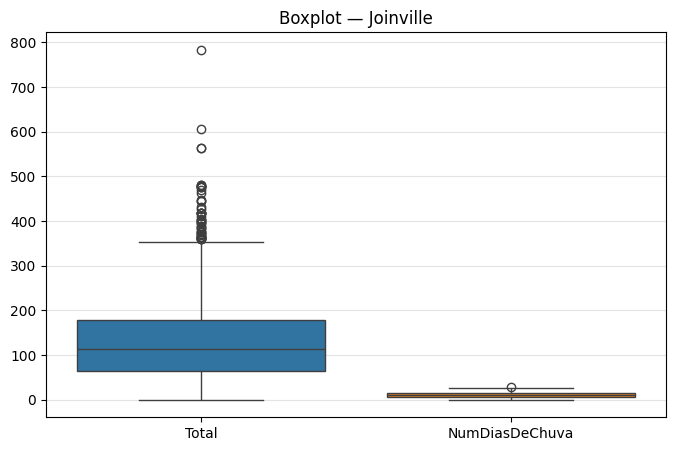

Joinville: outliers (EE) = 166 | válidos = 1490


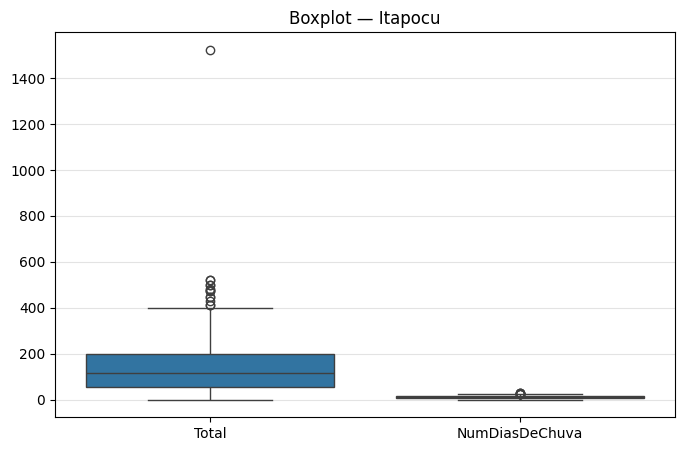

Itapocu: outliers (EE) = 90 | válidos = 808


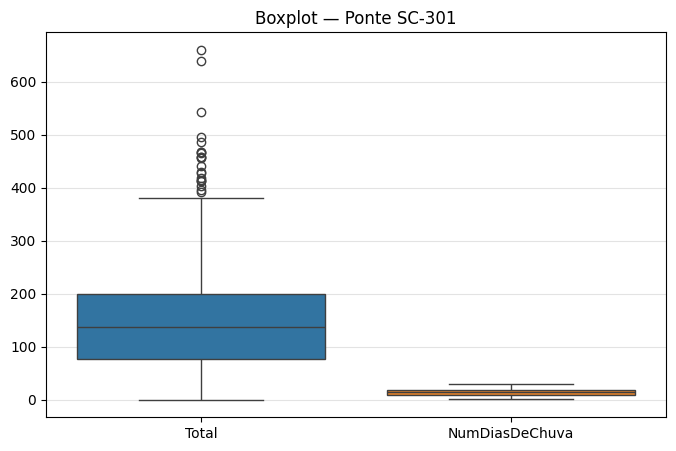

Ponte SC-301: outliers (EE) = 83 | válidos = 747


,Total,NumDiasDeChuva
829,21.4,9.0
828,21.4,9.0
826,48.0,12.0
827,48.0,12.0
824,48.2,10.0
...,...,...
4,189.9,21.0
3,23.6,13.0
2,126.3,13.0
1,234.2,20.0


In [39]:
def outliers_total_dias(df, nome='Estação', contamination=0.10, show=True):
    cols = ['Total', 'NumDiasDeChuva']
    base = df[[c for c in cols if c in df.columns]].dropna().copy()
    if base.empty:
        print(f"{nome}: base vazia após dropna."); return None

    if show:
        plt.figure(figsize=(8,5))
        sns.boxplot(data=base)
        plt.title(f'Boxplot — {nome}')
        plt.grid(True, axis='y', alpha=0.35)
        plt.show()

    try:
        ee = EllipticEnvelope(contamination=0.10)
        mask_ok = ee.fit_predict(base) == 1
        print(f"{nome}: outliers (EE) = {(~mask_ok).sum()} | válidos = {mask_ok.sum()}")
        return base.loc[mask_ok].copy()
    except Exception as e:
        print(f"{nome}: erro no EllipticEnvelope -> {e}")
        return None

outliers_total_dias(dfJ, 'Joinville')
outliers_total_dias(dfI, 'Itapocu')
outliers_total_dias(dfP, 'Ponte SC-301')